# Attenuator Calibration Lab Script

Dirty science-lab notebook for attenuator calibration. It has two paths:

- embedded auto-calibration: run firmware, retrieve retained HAC4 metadata and raw record chunks, and inspect them with helper plots;
- manual exploration: call `pcb.atten()`, wait, and read `pcb.pd()` so thresholds and failure modes can be changed quickly without reflashing.

Measure dark in a preceding cell or in the dark cell below before collecting either dataset.
The embedded firmware is the source of truth; the manual path below is intentionally written to mirror the current C state machine.



In [19]:

from __future__ import annotations

from dataclasses import dataclass
import math
import time
from typing import Literal

import matplotlib.pyplot as plt
import numpy as np

try:
    from scipy.optimize import least_squares
except ImportError:
    least_squares = None

import hispec_fibpcb as hspcb

BROKER = "hispec.caltech.edu"
LASER = "1028y"
OUTPUT = "yj_ao"
FIBER = "M"
PD_CHANNEL = "yj"

TAKE_DARK = False
DARK_DURATION_MS = 2000

MANUAL_FIT_METHOD: Literal["firmware", "scipy"] = "firmware"
MANUAL_DWELL_S = 0.55
MANUAL_DWELL_MS = int(round(MANUAL_DWELL_S * 1000))
MANUAL_SWEEP_STEP_MV = 50.0
MANUAL_COMPANION_SEARCH_MIN_STEP_MV = 5.0
MANUAL_COMPANION_SEARCH_MAX_TRIES = 16
MANUAL_MAX_RECORDS = 128
MANUAL_INITIAL_LASER_LEVELS_PCT = (100.0, 50.0, 5.0)
MANUAL_SNR_USABLE = hspcb.ATTENUATOR_CAL_SNR_USABLE
MANUAL_ADC_LSB_MV = 0.1875
MANUAL_DAC_SIGMA_MV = 3.0
MANUAL_FIT_MAX_ITER = 30
MANUAL_FIT_INITIAL_LAMBDA = 1.0e-3
MANUAL_FIT_MIN_SLOPE = 1.0e-12
MANUAL_FIT_MAX_SLOPE = 1.0
MANUAL_TAIL_FLOOR_POINTS = 3
MANUAL_RECORDS_PER_CHUNK = 37
TX_MIN = hspcb.ATTEN_CAL_MIN_TX
TX_MAX = hspcb.ATTEN_CAL_MAX_TX
MAX_DAC_MV = hspcb.ATTENUATOR_DRIVE_MAX_MV
ADC_CLIP_MV = hspcb.ATTENUATOR_ADC_CLIP_MV
GAIN = hspcb.ATTENUATOR_DEFAULT_GAIN
FIT_MIN_SIGMA_DB = hspcb.ATTENUATOR_FIT_MIN_SIGMA_DB

pcb = hspcb.HispecFibPcb(BROKER, connect=True)
pcb.status(), pcb.time()


(Status(
   fw='123e025a24b3-dirty',
   boots=9,
   board='tib',
   board_ok=True,
   mems_switches=8,
   relay_err=0,
   amb_c=21.812,
   pd_on_s=0,
   laserbank_on_s=271552,
   lastcmd=LastCommand(name='laser', src='mqtt', t_ms=271541681),
   ip=None,
   lasers=(),
   attens=()
 ),
 TimeStatus(utc=1782105210707, uptime_s=271553))

## Dark

Dark is deliberately outside attenuator calibration. Take or force the channel dark here, then leave calibration to read the photodiode configurable window.



In [20]:
pcb.pd(PD_CHANNEL)



PhotodiodeValues(
  yj=PhotodiodeChannelValues(
  raw=129,
  mv=24.188,
  net_mv=25.622,
  net_err_mv=1.21,
  power_uw=1e-06,
  power_err_uw=0,
  dark_mv=-1.434,
  dark_err_mv=1.195,
  window=PhotodiodeWindow(
  duration_ms=500,
  failed_samples=0,
  mean_mv=25.995,
  mean_net_mv=27.429,
  rms_mv=2.736,
  mean_net_err_mv=1.314,
  min_mv=20.062,
  max_mv=31.312,
  power_uw=1e-06,
  power_err_uw=0
),
  pd_is_off=False,
  ontime_s=0
),
  hk=None
)

In [3]:
if TAKE_DARK:
    pcb.pd_dark(PD_CHANNEL, duration_ms=DARK_DURATION_MS, persist=False)
pcb.pd(PD_CHANNEL)



PhotodiodeValues(
  yj=PhotodiodeChannelValues(
  raw=-8,
  mv=-1.5,
  net_mv=-0.066,
  net_err_mv=1.21,
  power_uw=0,
  power_err_uw=0,
  dark_mv=-1.434,
  dark_err_mv=1.195,
  window=PhotodiodeWindow(
  duration_ms=500,
  failed_samples=0,
  mean_mv=-1.673,
  mean_net_mv=-0.238,
  rms_mv=1.427,
  mean_net_err_mv=1.229,
  min_mv=-4.875,
  max_mv=1.5,
  power_uw=0,
  power_err_uw=0
),
  pd_is_off=False,
  ontime_s=3
),
  hk=None
)

## Embedded Firmware Path

Run the on-board algorithm, then fetch metadata plus fixed raw-record chunks. The Python helper derives bridge scale, scaled signal, transmission, dB attenuation, fit inclusion, residuals, and role markers from those records.



In [ ]:
embedded_status = pcb.atten_calibrate_auto(
    LASER,
    output=OUTPUT,
    fiber=FIBER,
    dwell_ms=MANUAL_DWELL_MS,
    persist=False,
)
embedded_status



In [ ]:
pcb.atten_calibration_status()



In [ ]:
embedded = pcb.atten_calibration_data(physical="all")
embedded



In [ ]:
embedded.bridge_table()



In [ ]:
embedded.plot_physical("dac1")
embedded.plot_physical("dac2")



In [ ]:
coeff = pcb.atten_coeff(LASER)
embedded.plot_surface(coeff.dac1, coeff.dac2, overlay_records=True)



## Manual Exploration Path

The manual path mirrors the current C algorithm:

1. For each physical FVOA, hold the DUT at 0 mV and binary-search the companion FVOA for the lowest usable companion DAC. Lower companion DAC means more light; higher companion DAC means more attenuation.
2. The selected usable `initial_probe` record is the open reference. There is no synthetic `reference` record and no repeated confirmation measurement.
3. Sweep the DUT linearly from 0 mV to `MAX_DAC_MV` using `MANUAL_SWEEP_STEP_MV`. Saturated sweep points are retained and skipped forward; below-SNR points trigger bridge normalization.
4. A bridge uses the latest usable retained `point` in the current segment as the before side, increments the segment, searches the companion FVOA, and stores the accepted `bridge_probe` record as the after side in the bridge table.
5. Fitting is done after acquisition in dB output space from raw records plus metadata. The firmware-style fit is a local finite-difference Gauss-Newton loop; the SciPy fit uses the same residuals and propagated dB uncertainty.



In [3]:

@dataclass
class CalRecord:
    physical: str
    event: Literal["point", "initial_probe", "bridge_probe"]
    classification: Literal["ok", "saturated", "below_snr", "adc_error"]
    segment: int
    sweep_mv: float
    other_mv: float
    laser_pct: float
    signal_mv: float
    signal_err_mv: float
    max_mv: float

    @property
    def usable(self) -> bool:
        return self.classification == "ok" and self.signal_mv > 0.0 and self.signal_err_mv > 0.0

    @property
    def acq_snr(self) -> float:
        return self.signal_mv / self.signal_err_mv if self.signal_err_mv > 0.0 else np.nan


@dataclass
class BridgeRole:
    before_record: int
    after_record: int


@dataclass
class CompanionSearch:
    low_mv: float
    high_mv: float
    candidate_record: int | None = None
    tries: int = 0

    def midpoint(self) -> float:
        return 0.5 * (self.low_mv + self.high_mv)

    def done(self) -> bool:
        return self.high_mv - self.low_mv <= MANUAL_COMPANION_SEARCH_MIN_STEP_MV or self.tries >= MANUAL_COMPANION_SEARCH_MAX_TRIES

    def note(self, rec: CalRecord, record_index: int) -> None:
        if rec.classification == "saturated":
            self.low_mv = rec.other_mv
        elif rec.classification == "ok":
            self.high_mv = rec.other_mv
            self.candidate_record = record_index
        elif rec.classification == "below_snr":
            self.high_mv = rec.other_mv
        else:
            raise RuntimeError(f"companion search failed at {rec.other_mv:.2f} mV: {rec.classification}")
        self.tries += 1


@dataclass
class CalRun:
    physical: Literal["dac1", "dac2"]
    records: list[CalRecord]
    reference_record: int | None = None
    bridges: list[BridgeRole] | None = None

    def __post_init__(self) -> None:
        if self.bridges is None:
            self.bridges = []

    def append(self, rec: CalRecord) -> int:
        self.records.append(rec)
        return len(self.records) - 1

    def to_recarray(self) -> np.recarray:
        rows = [
            (rec.physical, i, rec.event, rec.classification, int(rec.segment), float(rec.sweep_mv), float(rec.sweep_mv) * GAIN,
             float(rec.other_mv), float(rec.other_mv) * GAIN, float(rec.laser_pct), float(rec.signal_mv),
             float(rec.signal_err_mv), float(rec.max_mv))
            for i, rec in enumerate(self.records)
        ]
        return np.array(rows, dtype=hspcb.ATTEN_CAL_DTYPE).view(np.recarray)

    def to_dataset(self) -> hspcb.AttenuatorCalibrationDataset:
        return hspcb.AttenuatorCalibrationDataset(records=self.to_recarray(), meta=(self.run_metadata,))

    def derived(self) -> np.recarray:
        return self.to_dataset().derived()

    def fit_points(self) -> np.recarray:
        derived = self.derived()
        mask = derived.fit_candidate & np.isfinite(derived.db) & np.isfinite(derived.db_err)
        points = derived[mask].view(np.recarray)
        if len(points) < 6:
            raise RuntimeError(f"not enough fit records: {len(points)}")
        return points[np.argsort(points.sweep_mv)].view(np.recarray)

    def tail_floor(self, points: np.recarray | None = None, *, count: int = MANUAL_TAIL_FLOOR_POINTS) -> dict[str, object]:
        points = self.fit_points() if points is None else points[np.argsort(points.sweep_mv)].view(np.recarray)
        if len(points) < count:
            raise RuntimeError(f"not enough fit records for {count}-point tail floor")
        tail = points[-count:].view(np.recarray)
        max_atten_db = float(tail.db.mean())
        tail_sigma = float(tail.db.std(ddof=1) / np.sqrt(count)) if count > 1 else 0.0
        max_atten_sigma_db = max(tail_sigma, FIT_MIN_SIGMA_DB / np.sqrt(count))
        return {
            "max_atten_db": max_atten_db,
            "max_atten_sigma_db": float(max_atten_sigma_db),
            "floor_tx": float(10.0 ** (-max_atten_db / 10.0)),
            "tail_record_indices": tuple(int(value) for value in tail.record),
        }

    @property
    def run_metadata(self) -> dict:
        chunk_count = int(math.ceil(len(self.records) / MANUAL_RECORDS_PER_CHUNK)) if self.records else 0
        return {
            "state": "complete",
            "mode": "manual",
            "physical": self.physical,
            "fit_valid": False,
            "fit_accepted": False,
            "record_overflow": len(self.records) >= MANUAL_MAX_RECORDS,
            "record_size": hspcb._ATTEN_CAL_RECORD_BINARY.size,
            "records_per_chunk": MANUAL_RECORDS_PER_CHUNK,
            "record_count": len(self.records),
            "record_chunk_count": chunk_count,
            "reference_valid": self.reference_record is not None,
            "reference_record": int(self.reference_record or 0),
            "bridge_count": len(self.bridges or ()),
            "bridges": tuple(
                {"bridge_index": i, "before_record": int(bridge.before_record), "after_record": int(bridge.after_record)}
                for i, bridge in enumerate(self.bridges or ())
            ),
        }

    def save(self, file: str = "run.pickle") -> None:
        import pickle
        with open(file, "wb") as f:
            pickle.dump(self, f)

    @staticmethod
    def load(file: str = "run.pickle") -> "CalRun":
        import pickle
        with open(file, "rb") as f:
            return pickle.load(f)


def runs_to_dataset(*runs: CalRun) -> hspcb.AttenuatorCalibrationDataset:
    return hspcb.AttenuatorCalibrationDataset(records=np.hstack([run.to_recarray() for run in runs]), meta=tuple(run.run_metadata for run in runs))


In [4]:
def _set_pair(physical: str, sweep_mv: float, other_mv: float):
    sweep_mv = float(np.clip(sweep_mv, 0.0, MAX_DAC_MV))
    other_mv = float(np.clip(other_mv, 0.0, MAX_DAC_MV))
    if physical == "dac1":
        return pcb.atten(LASER, value1_mv=sweep_mv, value2_mv=other_mv)
    if physical == "dac2":
        return pcb.atten(LASER, value1_mv=other_mv, value2_mv=sweep_mv)
    raise ValueError("physical must be dac1 or dac2")


def _pd_window(channel: str = PD_CHANNEL):
    pd = pcb.pd(channel)
    pd_channel = getattr(pd, channel)
    if pd_channel is None:
        raise RuntimeError(f"pd/{channel} response did not include {channel}")
    return pd_channel.window


def _classify_window(window) -> tuple[str, float, float, float, float]:
    signal_mv = float(window.mean_net_mv)
    signal_err_mv = float(window.mean_net_err_mv)
    max_mv = float(window.max_mv)
    if not (signal_err_mv > 0.0 and np.isfinite(signal_err_mv)):
        signal_err_mv = MANUAL_ADC_LSB_MV
    if signal_mv >= ADC_CLIP_MV:
        return "saturated", signal_mv, signal_err_mv, max_mv, np.nan
    snr = signal_mv / signal_err_mv
    if signal_mv <= 0.0 or not np.isfinite(snr) or snr < MANUAL_SNR_USABLE:
        return "below_snr", signal_mv, signal_err_mv, max_mv, snr
    return "ok", signal_mv, signal_err_mv, max_mv, snr


def _print_record(rec: CalRecord) -> None:
    print(
        f"{rec.event:14s} {rec.physical}={rec.sweep_mv:8.2f} other={rec.other_mv:8.2f} "
        f"signal={rec.signal_mv:9.3f}+/-{rec.signal_err_mv:6.3f} "
        f"snr={rec.acq_snr:8.2f} classification={rec.classification:10s} segment={rec.segment}"
    )


def measure_point(
    run: CalRun,
    sweep_mv: float,
    other_mv: float,
    *,
    event: Literal["point", "initial_probe", "bridge_probe"],
    segment: int,
    laser_pct: float,
) -> tuple[int, CalRecord]:
    _set_pair(run.physical, sweep_mv, other_mv)
    time.sleep(MANUAL_DWELL_S)
    classification, signal_mv, signal_err_mv, max_mv, _snr = _classify_window(_pd_window(PD_CHANNEL))
    rec = CalRecord(
        physical=run.physical,
        event=event,
        classification=classification,
        segment=int(segment),
        sweep_mv=float(sweep_mv),
        other_mv=float(other_mv),
        laser_pct=float(laser_pct),
        signal_mv=signal_mv,
        signal_err_mv=signal_err_mv,
        max_mv=max_mv,
    )
    index = run.append(rec)
    _print_record(rec)
    return index, rec


def _next_linear_sweep_mv(sweep_mv: float, step_mv: float) -> float:
    return min(MAX_DAC_MV, float(sweep_mv) + float(step_mv))



In [5]:
def _initial_reference(run: CalRun, laser_levels_pct: tuple[float, ...]) -> tuple[float, float]:
    laser_index = 0
    laser_pct = float(laser_levels_pct[laser_index])
    pcb.set_laser_level(LASER, laser_pct)
    search = CompanionSearch(0.0, MAX_DAC_MV)

    while len(run.records) < MANUAL_MAX_RECORDS:
        index, rec = measure_point(
            run,
            0.0,
            search.midpoint(),
            event="initial_probe",
            segment=0,
            laser_pct=laser_pct,
        )
        search.note(rec, index)

        if (
            rec.classification == "saturated"
            and rec.other_mv >= MAX_DAC_MV - MANUAL_COMPANION_SEARCH_MIN_STEP_MV
        ):
            laser_index += 1
            if laser_index >= len(laser_levels_pct):
                raise RuntimeError(f"{run.physical} initial probe saturated at max companion attenuation")
            laser_pct = float(laser_levels_pct[laser_index])
            pcb.set_laser_level(LASER, laser_pct)
            search = CompanionSearch(0.0, MAX_DAC_MV)
            continue

        if search.done():
            if search.candidate_record is None:
                raise RuntimeError(f"{run.physical} initial companion search found no usable reference")
            run.reference_record = search.candidate_record
            return run.records[search.candidate_record].other_mv, laser_pct

    raise RuntimeError(f"{run.physical} exceeded manual record budget during initial search")


def _latest_bridge_anchor(run: CalRun, segment: int) -> tuple[int | None, CalRecord | None, bool]:
    count = 0
    all_below_snr = True
    for index in range(len(run.records) - 1, -1, -1):
        rec = run.records[index]
        if rec.segment == segment and rec.event == "point":
            count += 1
            if rec.classification != "below_snr":
                all_below_snr = False
            if rec.classification == "ok":
                return index, rec, False
    if all_below_snr and count == 1 and segment > 0:
        return None, None, True
    raise RuntimeError(f"{run.physical} has no usable bridge anchor in segment {segment}")


def _bridge_normalize(
    run: CalRun,
    *,
    segment: int,
    other_mv: float,
    step_mv: float,
    laser_pct: float,
) -> tuple[bool, int, float, float]:
    if other_mv <= MANUAL_COMPANION_SEARCH_MIN_STEP_MV:
        return True, segment, other_mv, MAX_DAC_MV

    before_index, anchor, done = _latest_bridge_anchor(run, segment)
    if done:
        return True, segment, other_mv, MAX_DAC_MV
    assert anchor is not None and before_index is not None

    segment += 1
    search = CompanionSearch(0.0, other_mv)
    while len(run.records) < MANUAL_MAX_RECORDS:
        index, rec = measure_point(
            run,
            anchor.sweep_mv,
            search.midpoint(),
            event="bridge_probe",
            segment=segment,
            laser_pct=laser_pct,
        )
        search.note(rec, index)

        if not search.done():
            continue

        if search.candidate_record is None:
            search_floor = 0.0
            for prior in reversed(run.records):
                if prior.event == "bridge_probe" and prior.segment == segment:
                    if prior.classification == "saturated":
                        search_floor = max(search_floor, prior.other_mv)
                        break
            if search_floor == 0.0:
                print(f"{run.physical} bridge probes were all below SNR; finishing physical")
                return True, segment, other_mv, MAX_DAC_MV
            if abs(search_floor - other_mv) < MANUAL_COMPANION_SEARCH_MIN_STEP_MV:
                raise RuntimeError(f"{run.physical} bridge search found no viable companion point")
            search = CompanionSearch(search_floor, other_mv)
            continue

        after_index = search.candidate_record
        before = run.records[before_index]
        after = run.records[after_index]
        ratio = after.signal_mv / before.signal_mv if before.signal_mv > 0.0 else np.nan
        if not (ratio > 1.0 and np.isfinite(ratio)):
            raise RuntimeError(f"{run.physical} bridge ratio is invalid: {ratio}")
        run.bridges.append(BridgeRole(before_record=before_index, after_record=after_index))
        next_sweep = _next_linear_sweep_mv(anchor.sweep_mv, step_mv)
        return False, segment, after.other_mv, next_sweep

    raise RuntimeError(f"{run.physical} exceeded manual record budget during bridge search")


def acquire_physical(
    physical: Literal["dac1", "dac2"],
    *,
    step_mv: float = MANUAL_SWEEP_STEP_MV,
    laser_levels_pct: tuple[float, ...] = MANUAL_INITIAL_LASER_LEVELS_PCT,
) -> CalRun:
    run = CalRun(physical=physical, records=[])
    segment = 0
    sweep_mv = 0.0
    other_mv, laser_pct = _initial_reference(run, laser_levels_pct)

    while len(run.records) < MANUAL_MAX_RECORDS:
        _index, rec = measure_point(
            run,
            sweep_mv,
            other_mv,
            event="point",
            segment=segment,
            laser_pct=laser_pct,
        )

        if rec.classification in ("ok", "saturated"):
            if sweep_mv >= MAX_DAC_MV:
                break
            sweep_mv = _next_linear_sweep_mv(sweep_mv, step_mv)
            continue

        if rec.classification == "below_snr":
            if sweep_mv >= MAX_DAC_MV:
                break
            done, segment, other_mv, sweep_mv = _bridge_normalize(
                run,
                segment=segment,
                other_mv=other_mv,
                step_mv=step_mv,
                laser_pct=laser_pct,
            )
            if done:
                break
            continue

        raise RuntimeError(f"{physical} sweep failed: {rec.classification}")

    return run



## Model Functions

In [34]:
from scipy.special import erf
erf(2).clip(0)

np.float64(0.9953222650189527)

In [51]:

ATTENUATOR_MODEL_ERF_SCALE = hspcb.ATTENUATOR_MODEL_ERF_SCALE


def _atten_model_tx_from_b(b):
    from scipy.special import erf
    b = np.asarray(b, dtype=float)
    erf_scale = erf(ATTENUATOR_MODEL_ERF_SCALE)
    return np.clip((erf_scale - erf(b)) / (2.0 * erf_scale), 0.0, 1.0)


def _atten_model_b_from_tx(tx):
    from scipy.special import erfinv, erf
    tx = np.asarray(tx, dtype=float)
    erf_scale = erf(ATTENUATOR_MODEL_ERF_SCALE)
    arg = erf_scale - 2.0 * erf_scale * np.clip(tx, 1.0e-300, 1.0)
    return erfinv(np.clip(arg, -erf_scale, erf_scale))

def _atten_model_b_from_db(db):
    return _atten_model_b_from_tx(10.0 ** (-np.asarray(db, dtype=float) / 10.0))


def _atten_db_from_tx(tx):
    return -10.0 * np.log10(np.clip(np.asarray(tx, dtype=float), 1.0e-300, 1.0))


def _atten_floor_tx(max_atten_db: float) -> float:
    return float(10.0 ** (-float(max_atten_db) / 10.0))


_atten_model_tx_from_b(0), _atten_db_from_tx(_atten_floor_tx(48.35))


(np.float64(0.5), np.float64(48.35))

In [47]:

def _atten_b_from_coeff(params, dac_mv, *, gain: float = GAIN):
    fvoa_50pct_mv, slope_inv_fvoa_mv = np.asarray(params, dtype=float)[:2]
    dac = np.asarray(dac_mv, dtype=float)
    return slope_inv_fvoa_mv * (gain * dac - fvoa_50pct_mv)


def _atten_ideal_relative_tx_from_coeff(params, dac_mv, *, gain: float = GAIN):
    b = _atten_b_from_coeff(params, dac_mv, gain=gain)
    open_tx = _atten_model_tx_from_b(_atten_b_from_coeff(params, [0.0], gain=gain))[0]
    if not np.isfinite(open_tx) or open_tx <= 0.0:
        return np.full_like(np.asarray(dac_mv, dtype=float), np.nan, dtype=float)
    return np.clip(_atten_model_tx_from_b(b) / open_tx, 0.0, 1.0)


def _atten_relative_tx_from_coeff(params, dac_mv, *, max_atten_db: float, gain: float = GAIN):
    ideal_tx = _atten_ideal_relative_tx_from_coeff(params, dac_mv, gain=gain)
    floor_tx = _atten_floor_tx(max_atten_db)
    return np.clip(floor_tx + (1.0 - floor_tx) * ideal_tx, 1.0e-300, 1.0)


def _atten_db_from_coeff(params, dac_mv, *, max_atten_db: float, gain: float = GAIN):
    return _atten_db_from_tx(_atten_relative_tx_from_coeff(params, dac_mv, max_atten_db=max_atten_db, gain=gain))


def _manual_model_db(params, dac_mv, *, max_atten_db: float, gain: float = GAIN):
    return _atten_db_from_coeff(params, dac_mv, max_atten_db=max_atten_db, gain=gain)


def _manual_model_d_db_d_dac(params, dac_mv, *, max_atten_db: float, gain: float = GAIN):
    step = max(MANUAL_DAC_SIGMA_MV, 0.5)
    dac = np.asarray(dac_mv, dtype=float)
    lo = np.clip(dac - step, 0.0, MAX_DAC_MV)
    hi = np.clip(dac + step, 0.0, MAX_DAC_MV)
    return (_manual_model_db(params, hi, max_atten_db=max_atten_db, gain=gain) - _manual_model_db(params, lo, max_atten_db=max_atten_db, gain=gain)) / np.maximum(hi - lo, 1.0e-12)


def _manual_model_d_db_d_max_atten(params, dac_mv, *, max_atten_db: float, gain: float = GAIN):
    ideal_tx = _atten_ideal_relative_tx_from_coeff(params, dac_mv, gain=gain)
    floor_tx = _atten_floor_tx(max_atten_db)
    model_tx = floor_tx + (1.0 - floor_tx) * ideal_tx
    return floor_tx * (1.0 - ideal_tx) / np.maximum(model_tx, 1.0e-300)


In [8]:

if "dac1_run" in globals():
    points = dac1_run.fit_points()
    floor = dac1_run.tail_floor(points)
    plt.errorbar(points.sweep_mv * GAIN, points.db, yerr=np.maximum(points.db_err, FIT_MIN_SIGMA_DB), fmt=".")
    plt.scatter(points.sweep_mv[-MANUAL_TAIL_FLOOR_POINTS:] * GAIN, points.db[-MANUAL_TAIL_FLOOR_POINTS:], marker="D", facecolors="none", edgecolors="tab:red", s=70)
    plt.axhline(floor["max_atten_db"], color="tab:red", linewidth=0.9)
    floor


In [9]:

def _manual_fit_points(run: CalRun):
    return run.fit_points()


def _manual_floor(run: CalRun, points=None):
    return run.tail_floor(_manual_fit_points(run) if points is None else points)


def _manual_weighted_residual(params, points, floor: dict[str, object], *, gain: float = GAIN):
    max_atten_db = float(floor["max_atten_db"])
    max_atten_sigma_db = float(floor["max_atten_sigma_db"])
    model = _manual_model_db(params, points.sweep_mv, max_atten_db=max_atten_db, gain=gain)
    d_db_d_dac = _manual_model_d_db_d_dac(params, points.sweep_mv, max_atten_db=max_atten_db, gain=gain)
    d_db_d_max = _manual_model_d_db_d_max_atten(params, points.sweep_mv, max_atten_db=max_atten_db, gain=gain)
    sigma = np.hypot(points.db_err, d_db_d_dac * MANUAL_DAC_SIGMA_MV)
    sigma = np.hypot(sigma, d_db_d_max * max_atten_sigma_db)
    sigma = np.maximum(sigma, FIT_MIN_SIGMA_DB)
    return (model - points.db) / sigma


def _manual_initial_guess(points, *, gain: float = GAIN):
    x = points.sweep_mv * gain
    db = points.db
    f50 = float(x[np.abs(db - 3.01029995664).argmin()])
    slope = 8.0 / (x.max() - x.min()) if x.max() > x.min() else 8.0 / (MAX_DAC_MV * gain)
    return np.array([np.clip(f50, 1.0, 2.0 * MAX_DAC_MV * gain), np.clip(slope, MANUAL_FIT_MIN_SLOPE, MANUAL_FIT_MAX_SLOPE)])


def _fit_records_firmware_style(run: CalRun, *, gain: float = GAIN):
    points = _manual_fit_points(run)
    floor = _manual_floor(run, points)
    params = _manual_initial_guess(points, gain=gain)
    cost = float((_manual_weighted_residual(params, points, floor, gain=gain) ** 2).sum())
    lam = MANUAL_FIT_INITIAL_LAMBDA
    max_fvoa_mv = MAX_DAC_MV * gain

    for _ in range(MANUAL_FIT_MAX_ITER):
        r = _manual_weighted_residual(params, points, floor, gain=gain)
        step = np.array([max(abs(params[0]) * 1.0e-5, 0.1), max(abs(params[1]) * 1.0e-5, 1.0e-8)])
        jac = np.column_stack([
            (_manual_weighted_residual(params + [step[0], 0.0], points, floor, gain=gain) - r) / step[0],
            (_manual_weighted_residual(params + [0.0, step[1]], points, floor, gain=gain) - r) / step[1],
        ])
        h = jac.T @ jac + lam * np.eye(2)
        g = jac.T @ r
        try:
            delta = -np.linalg.solve(h, g)
        except np.linalg.LinAlgError as exc:
            raise RuntimeError("firmware-style fit became singular") from exc

        trial = np.array([
            np.clip(params[0] + delta[0], 1.0, 2.0 * max_fvoa_mv),
            np.clip(params[1] + delta[1], MANUAL_FIT_MIN_SLOPE, MANUAL_FIT_MAX_SLOPE),
        ])
        trial_cost = float((_manual_weighted_residual(trial, points, floor, gain=gain) ** 2).sum())
        if np.isfinite(trial_cost) and trial_cost < cost:
            if np.allclose(trial, params, rtol=0.0, atol=[1.0e-6, 1.0e-12]):
                params = trial
                cost = trial_cost
                break
            params = trial
            cost = trial_cost
            lam = max(lam * 0.3, 1.0e-12)
        else:
            lam = min(lam * 10.0, 1.0e12)

    return _manual_fit_summary("firmware", run, points, params, floor, gain=gain)


def _fit_records_scipy(run: CalRun, *, gain: float = GAIN):
    if least_squares is None:
        raise RuntimeError("scipy is not installed")
    points = _manual_fit_points(run)
    floor = _manual_floor(run, points)
    initial = _manual_initial_guess(points, gain=gain)
    result = least_squares(
        lambda p: _manual_weighted_residual(p, points, floor, gain=gain),
        initial,
        bounds=([1.0, MANUAL_FIT_MIN_SLOPE], [2.0 * MAX_DAC_MV * gain, MANUAL_FIT_MAX_SLOPE]),
        loss="linear",
        max_nfev=5000,
    )
    return _manual_fit_summary("scipy", run, points, result.x, floor, gain=gain, success=bool(result.success))


def _manual_fit_summary(method: str, run: CalRun, points, params, floor: dict[str, object], *, gain: float = GAIN, success: bool = True):
    max_atten_db = float(floor["max_atten_db"])
    model = _manual_model_db(params, points.sweep_mv, max_atten_db=max_atten_db, gain=gain)
    residual = model - points.db
    return {
        "method": method,
        "physical": run.physical,
        "accepted": bool(success and params[0] > 0.0 and params[1] > 0.0 and max_atten_db > 0.0),
        "points": int(len(points)),
        "fvoa_50pct_mv": float(params[0]),
        "slope_inv_fvoa_mv": float(params[1]),
        "max_atten_db": max_atten_db,
        "max_atten_sigma_db": float(floor["max_atten_sigma_db"]),
        "floor_tx": float(floor["floor_tx"]),
        "gain": float(gain),
        "rms_db": float(np.sqrt((residual * residual).mean())),
        "max_abs_db": float(np.abs(residual).max()),
        "min_tx": float(points.tx.min()),
        "max_tx": float(points.tx.max()),
        "tail_record_indices": tuple(floor["tail_record_indices"]),
    }


def fit_records(run: CalRun, *, method: str = MANUAL_FIT_METHOD, gain: float = GAIN):
    if method == "firmware":
        return _fit_records_firmware_style(run, gain=gain)
    if method == "scipy":
        return _fit_records_scipy(run, gain=gain)
    raise ValueError("method must be 'firmware' or 'scipy'")


In [10]:

def plot_manual_records(run: CalRun, fit: dict[str, float | int | bool]):
    coeff = (float(fit["fvoa_50pct_mv"]), float(fit["slope_inv_fvoa_mv"]), float(fit["max_atten_db"]), float(fit["gain"]))
    dataset = run.to_dataset()
    derived = dataset.derived(dac1=coeff if run.physical == "dac1" else None, dac2=coeff if run.physical == "dac2" else None)
    rec = derived[np.asarray(derived.physical).astype(str) == run.physical].view(np.recarray)
    fvoa = rec.fvoa_mv
    events = np.asarray(rec.event).astype(str)
    classifications = np.asarray(rec.classification).astype(str)
    included = np.asarray(rec.included, dtype=bool)
    tail_indices = np.asarray(fit.get("tail_record_indices", ()), dtype=int)
    tail = np.isin(np.asarray(rec.record, dtype=int), tail_indices)

    fig, axes = plt.subplots(4, 1, figsize=(9, 10), sharex=True, constrained_layout=True)
    fig.suptitle(f"{run.physical} manual calibration records, max_atten_db={fit['max_atten_db']:.3f}+/-{fit['max_atten_sigma_db']:.3f}")

    axes[0].set_title("raw dark-subtracted signal")
    finite_signal = np.isfinite(rec.signal_mv) & np.isfinite(rec.signal_err_mv)
    axes[0].errorbar(fvoa[finite_signal], rec.signal_mv[finite_signal], yerr=rec.signal_err_mv[finite_signal], fmt="none", ecolor="0.65", linewidth=0.7)
    axes[0].set_ylabel("signal_mv")

    axes[1].set_title("bridge-scaled signal")
    finite_scaled = np.isfinite(rec.scaled_signal_mv) & np.isfinite(rec.scaled_signal_err_mv)
    axes[1].errorbar(fvoa[finite_scaled], rec.scaled_signal_mv[finite_scaled], yerr=rec.scaled_signal_err_mv[finite_scaled], fmt="none", ecolor="0.65", linewidth=0.7)
    axes[1].set_ylabel("scaled_signal_mv")

    axes[2].set_title("attenuation from normalized transmission")
    finite_db = np.isfinite(rec.db) & np.isfinite(rec.db_err)
    axes[2].errorbar(fvoa[finite_db], rec.db[finite_db], yerr=np.maximum(rec.db_err[finite_db], FIT_MIN_SIGMA_DB), fmt="none", ecolor="0.65", linewidth=0.7)
    grid_dac = np.linspace(0.0, MAX_DAC_MV, 500)
    axes[2].plot(grid_dac * coeff[3], _atten_db_from_coeff(coeff[:2], grid_dac, max_atten_db=coeff[2], gain=coeff[3]), color="black", linewidth=1.0, label=f"{fit['method']} fit")
    axes[2].axhline(float(fit["max_atten_db"]), color="tab:red", linestyle="--", linewidth=0.9, label="tail floor")
    axes[2].set_ylabel("attenuation_db")
    axes[2].legend(loc="best")

    event_colors = {"point": "tab:blue", "initial_probe": "0.55", "bridge_probe": "tab:green"}
    event_markers = {"point": "o", "initial_probe": "s", "bridge_probe": "P"}
    for event in dict.fromkeys(events):
        mask = events == event
        color = event_colors.get(event, "0.35")
        marker = event_markers.get(event, "o")
        axes[0].scatter(fvoa[mask], rec.signal_mv[mask], marker=marker, color=color, s=32, alpha=0.82, label=event)
        axes[1].scatter(fvoa[mask], rec.scaled_signal_mv[mask], marker=marker, color=color, s=32, alpha=0.82)
        axes[2].scatter(fvoa[mask], rec.db[mask], marker=marker, color=color, s=32, alpha=0.82)

    role_styles = {"reference": ("*", "tab:cyan"), "bridge_before": ("^", "tab:orange"), "bridge_after": ("v", "tab:red")}
    for role, indices in dataset._role_record_indices(run.physical).items():
        if not indices:
            continue
        mask = np.isin(np.asarray(rec.record, dtype=int), np.asarray(indices, dtype=int))
        marker, color = role_styles[role]
        for ax, y in zip(axes[:3], (rec.signal_mv, rec.scaled_signal_mv, rec.db), strict=False):
            finite = mask & np.isfinite(y)
            if finite.any():
                ax.scatter(fvoa[finite], y[finite], marker=marker, facecolors="none", edgecolors=color, s=92, linewidths=1.2, label=role)

    bad = classifications != "ok"
    axes[0].scatter(fvoa[bad], rec.signal_mv[bad], marker="x", color="black", s=38, label="not ok")
    axes[2].scatter(fvoa[tail], rec.db[tail], marker="D", facecolors="none", edgecolors="tab:red", s=82, linewidths=1.3, label="tail fit")
    axes[0].legend(loc="best", fontsize="small")

    axes[3].axhline(0.0, color="0.35", linestyle="--", linewidth=0.8)
    axes[3].scatter(fvoa[included], rec.residual_db[included], color="black", s=24)
    axes[3].scatter(fvoa[tail], rec.residual_db[tail], marker="D", facecolors="none", edgecolors="tab:red", s=82, linewidths=1.3)
    axes[3].set_ylabel("residual_db")
    axes[3].set_xlabel("swept FVOA drive (mV)")
    return fig


## Gather Data And Fit

In [ ]:
dac1_run = acquire_physical("dac1", step_mv=MANUAL_SWEEP_STEP_MV)
dac1_fit = fit_records(dac1_run, method=MANUAL_FIT_METHOD)
dac1_fit



In [ ]:

# dac1_run.save("dac1_run.pickle")


## Explore and Play

In [11]:

dac1_run = CalRun.load("dac1_run.pickle")


In [12]:
dac1_run.to_dataset()

AttenuatorCalibrationDataset(records=88, physicals=('dac1',), counts=(('dac1', 88),))

In [49]:
dac1_fit = fit_records(dac1_run, method="firmware")
dac1_fit

{'method': 'firmware',
 'physical': 'dac1',
 'accepted': True,
 'points': 64,
 'fvoa_50pct_mv': 3743.0305922330567,
 'slope_inv_fvoa_mv': 0.00274021315682405,
 'max_atten_db': 48.35789515980114,
 'max_atten_sigma_db': 0.2886751345948129,
 'floor_tx': 1.4595214567130895e-05,
 'gain': 1.533,
 'rms_db': 0.7875871289472797,
 'max_abs_db': 2.5306292491616134,
 'min_tx': 1.444383776730102e-05,
 'max_tx': 0.999748926148974,
 'tail_record_indices': (85, 86, 87)}

{'method': 'scipy',
 'physical': 'dac1',
 'accepted': True,
 'points': 64,
 'fvoa_50pct_mv': 3743.0226501214997,
 'slope_inv_fvoa_mv': 0.0027401786052877316,
 'max_atten_db': 48.35789515980114,
 'max_atten_sigma_db': 0.2886751345948129,
 'floor_tx': 1.4595214567130895e-05,
 'gain': 1.533,
 'rms_db': 0.7875737604436528,
 'max_abs_db': 2.53045709794754,
 'min_tx': 1.444383776730102e-05,
 'max_tx': 0.999748926148974,
 'tail_record_indices': (85, 86, 87)}

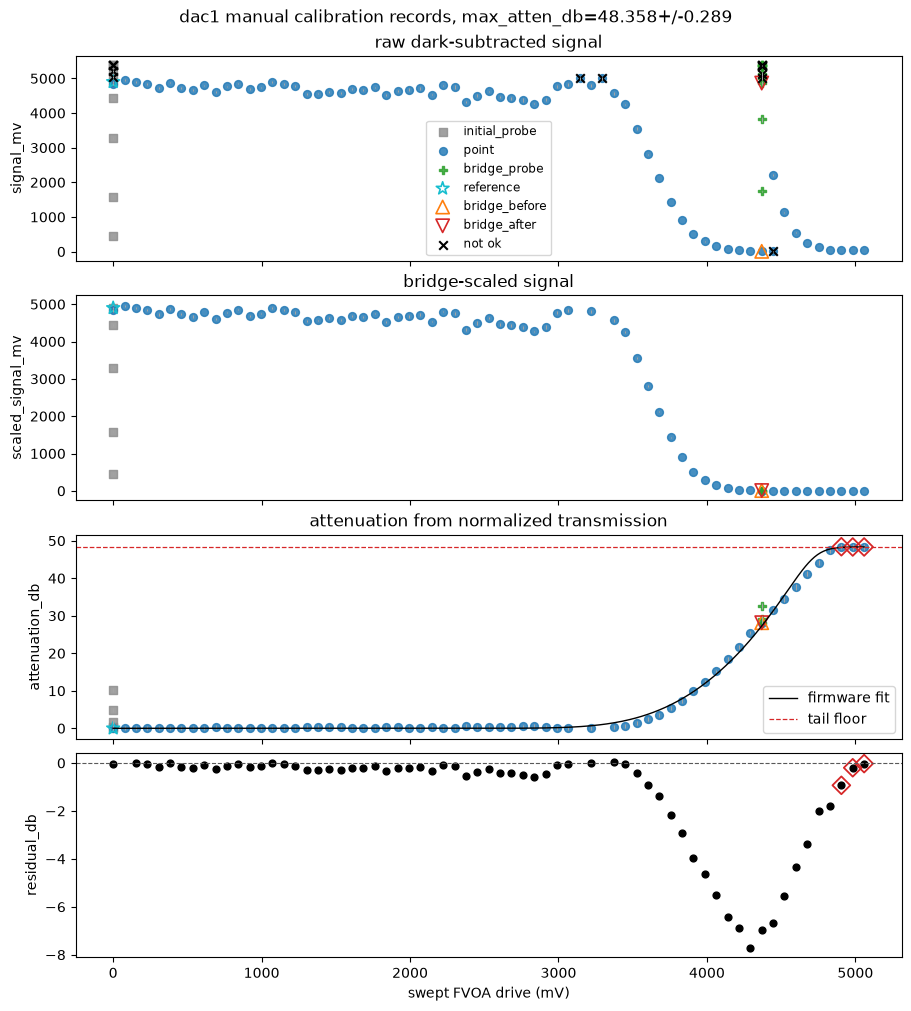

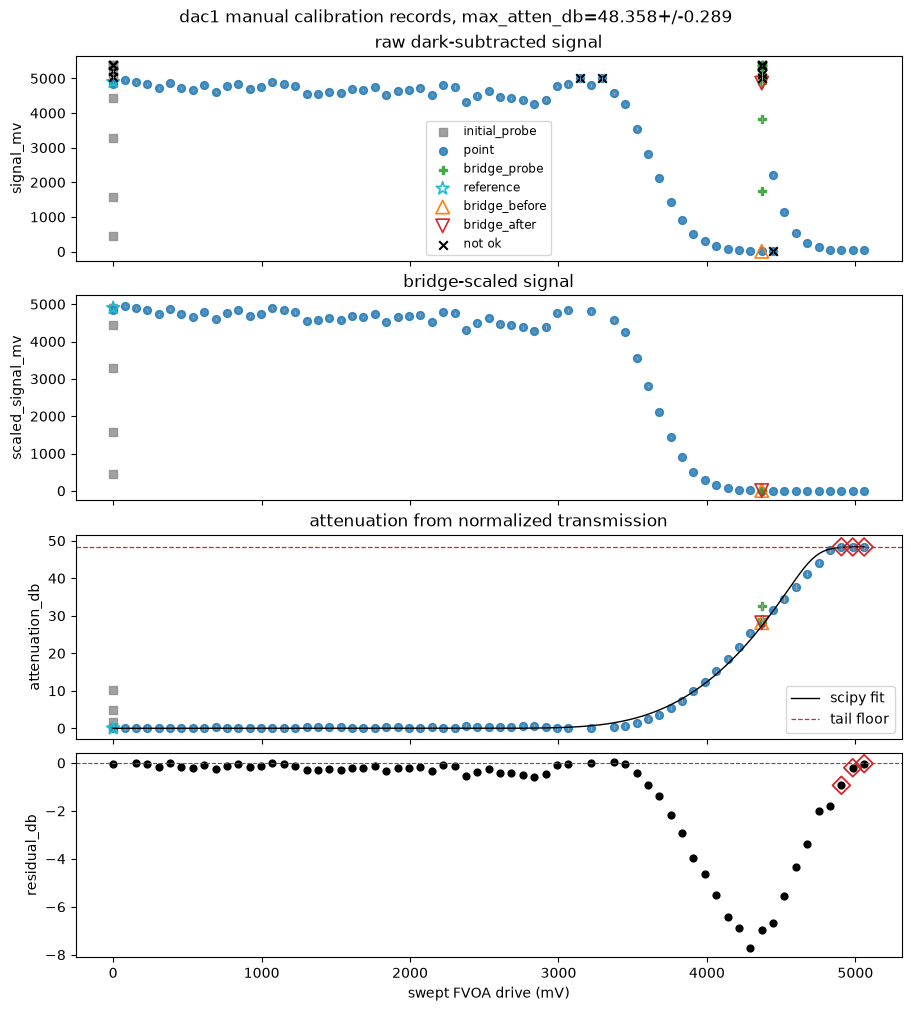

In [50]:
plot_manual_records(dac1_run, dac1_fit);
dac1_fit_sp = fit_records(dac1_run, method="scipy")
plot_manual_records(dac1_run, dac1_fit_sp);
dac1_fit_sp

In [21]:
dac2_run = acquire_physical("dac2", step_mv=MANUAL_SWEEP_STEP_MV)
dac2_fit = fit_records(dac2_run, method=MANUAL_FIT_METHOD)
dac2_fit


initial_probe  dac2=    0.00 other= 1650.00 signal= 5379.024+/- 1.195 snr= 4501.28 classification=saturated  segment=0
initial_probe  dac2=    0.00 other= 2475.00 signal= 5378.919+/- 1.195 snr= 4501.19 classification=saturated  segment=0
initial_probe  dac2=    0.00 other= 2887.50 signal= 5378.829+/- 1.195 snr= 4501.11 classification=saturated  segment=0
initial_probe  dac2=    0.00 other= 3093.75 signal= 2196.932+/-23.128 snr=   94.99 classification=ok         segment=0
initial_probe  dac2=    0.00 other= 2990.62 signal= 5379.002+/- 1.196 snr= 4497.49 classification=saturated  segment=0
initial_probe  dac2=    0.00 other= 3042.19 signal= 4048.209+/-40.340 snr=  100.35 classification=ok         segment=0
initial_probe  dac2=    0.00 other= 3016.41 signal= 5372.867+/- 7.065 snr=  760.49 classification=saturated  segment=0
initial_probe  dac2=    0.00 other= 3029.30 signal= 4506.924+/-49.501 snr=   91.05 classification=ok         segment=0
initial_probe  dac2=    0.00 other= 3022.85 sign

PCB warning photodiode_noise: photodiode fixed-window RMS exceeded warning threshold context=channel=yj fixed_rms_mv=284.283 threshold_mv=10.000 uptime_s=0


point          dac2= 1800.00 other= 3026.07 signal= 3813.204+/-60.158 snr=   63.39 classification=ok         segment=0
point          dac2= 1850.00 other= 3026.07 signal= 3864.287+/-39.305 snr=   98.32 classification=ok         segment=0
point          dac2= 1900.00 other= 3026.07 signal= 3529.247+/-43.624 snr=   80.90 classification=ok         segment=0
point          dac2= 1950.00 other= 3026.07 signal= 3232.689+/-30.043 snr=  107.60 classification=ok         segment=0
point          dac2= 2000.00 other= 3026.07 signal= 2863.179+/-13.224 snr=  216.51 classification=ok         segment=0
point          dac2= 2050.00 other= 3026.07 signal= 2320.779+/-16.338 snr=  142.05 classification=ok         segment=0
point          dac2= 2100.00 other= 3026.07 signal= 1789.787+/-11.569 snr=  154.71 classification=ok         segment=0
point          dac2= 2150.00 other= 3026.07 signal= 1220.117+/-22.970 snr=   53.12 classification=ok         segment=0
point          dac2= 2200.00 other= 3026.07 sign

PCB warning photodiode_adc_error: photodiode ADC sample discarded context=channel=hk rc=-5 uptime_s=0
PCB warning photodiode_adc_error: photodiode ADC sample discarded context=channel=yj rc=-5 uptime_s=0


point          dac2= 2600.00 other= 3026.07 signal=    5.754+/- 1.217 snr=    4.73 classification=below_snr  segment=0
bridge_probe   dac2= 2550.00 other= 1513.04 signal= 5379.032+/- 1.195 snr= 4501.28 classification=saturated  segment=1
bridge_probe   dac2= 2550.00 other= 2269.56 signal= 5378.889+/- 1.196 snr= 4497.40 classification=saturated  segment=1
bridge_probe   dac2= 2550.00 other= 2647.81 signal= 3195.482+/- 8.993 snr=  355.33 classification=ok         segment=1
bridge_probe   dac2= 2550.00 other= 2458.69 signal= 5378.837+/- 1.195 snr= 4501.12 classification=saturated  segment=1
bridge_probe   dac2= 2550.00 other= 2553.25 signal= 5378.852+/- 1.195 snr= 4501.13 classification=saturated  segment=1
bridge_probe   dac2= 2550.00 other= 2600.53 signal= 5379.939+/- 1.195 snr= 4502.04 classification=saturated  segment=1
bridge_probe   dac2= 2550.00 other= 2624.17 signal= 4265.454+/-12.385 snr=  344.40 classification=ok         segment=1
bridge_probe   dac2= 2550.00 other= 2612.35 sign

PCB warning photodiode_noise: photodiode fixed-window RMS exceeded warning threshold context=channel=hk fixed_rms_mv=18.718 threshold_mv=10.000 uptime_s=0


bridge_probe   dac2= 3000.00 other=   40.86 signal=  146.927+/- 2.749 snr=   53.45 classification=ok         segment=2
bridge_probe   dac2= 3000.00 other=   20.43 signal=  158.079+/- 1.642 snr=   96.27 classification=ok         segment=2
bridge_probe   dac2= 3000.00 other=   10.22 signal=  155.439+/- 3.652 snr=   42.56 classification=ok         segment=2
bridge_probe   dac2= 3000.00 other=    5.11 signal=  155.934+/- 3.811 snr=   40.92 classification=ok         segment=2
bridge_probe   dac2= 3000.00 other=    2.55 signal=  178.509+/- 4.593 snr=   38.87 classification=ok         segment=2
point          dac2= 3050.00 other=    2.55 signal=   87.857+/- 1.730 snr=   50.78 classification=ok         segment=2
point          dac2= 3100.00 other=    2.55 signal=   59.484+/- 2.009 snr=   29.61 classification=ok         segment=2
point          dac2= 3150.00 other=    2.55 signal=   34.217+/- 1.458 snr=   23.47 classification=ok         segment=2
point          dac2= 3200.00 other=    2.55 sign

PCB warning photodiode_adc_error: photodiode ADC sample discarded context=channel=hk rc=-5 uptime_s=0
PCB warning photodiode_adc_error: photodiode ADC sample discarded context=channel=yj rc=-5 uptime_s=0


point          dac2= 3250.00 other=    2.55 signal=   29.109+/- 1.334 snr=   21.82 classification=ok         segment=2
point          dac2= 3300.00 other=    2.55 signal=   26.012+/- 1.378 snr=   18.88 classification=ok         segment=2


{'method': 'firmware',
 'physical': 'dac2',
 'accepted': True,
 'points': 67,
 'fvoa_50pct_mv': 3004.098792231707,
 'slope_inv_fvoa_mv': 0.0021412590074377847,
 'max_atten_db': 61.949088191341275,
 'max_atten_sigma_db': 0.2886751345948129,
 'floor_tx': 6.383975047643551e-07,
 'gain': 1.533,
 'rms_db': 1.3685383754070783,
 'max_abs_db': 5.17782325219283,
 'min_tx': 5.838879801422614e-07,
 'max_tx': 0.9841722451912445,
 'tail_record_indices': (96, 97, 98)}

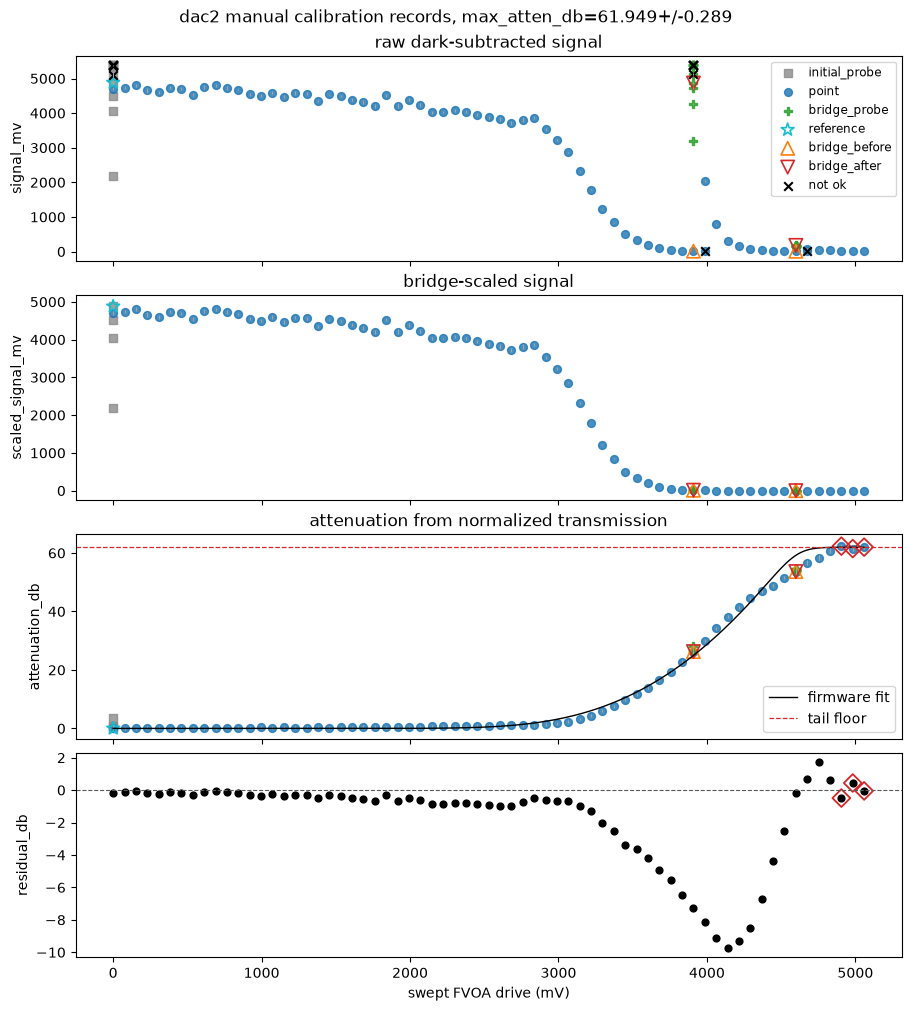

In [48]:
dac2_fit = fit_records(dac2_run, method=MANUAL_FIT_METHOD)
dac2_fit, plot_manual_records(dac2_run, dac2_fit);


In [23]:
manual_records = [asdict(record) for record in dac1_run.records + dac2_run.records]
manual_coeff = {
    "dac1": {k: dac1_fit[k] for k in ("fvoa_50pct_mv", "slope_inv_fvoa_mv", "gain")},
    "dac2": {k: dac2_fit[k] for k in ("fvoa_50pct_mv", "slope_inv_fvoa_mv", "gain")},
}
manual_dataset = runs_to_dataset(dac1_run, dac2_run)
manual_coeff


NameError: name 'asdict' is not defined

PCB warning photodiode_noise: photodiode fixed-window RMS exceeded warning threshold context=channel=yj fixed_rms_mv=10.294 threshold_mv=10.000 uptime_s=0


In [ ]:
manual_dataset.bridge_table()


In [ ]:
manual_dataset.plot_surface(manual_coeff["dac1"], manual_coeff["dac2"], overlay_records=True)


In [ ]:
# Review plots before applying. Keep persist=False until repeated and accepted.
# pcb.set_atten_coeff(LASER, manual_coeff["dac1"], manual_coeff["dac2"], persist=False)

